In [143]:
import pandas as pd

In [144]:
df = pd.read_csv("/Users/james/Projects/MuseumsNotebook/museums.csv")
df2 = pd.read_csv("/Users/james/Projects/MuseumsNotebook/state_pop_data.csv")


/var/folders/f_/93v_b49109x0tkj367ph296m0000gp/T/ipykernel_33249/2765256772.py:1: DtypeWarning: Columns (9,14,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/james/Projects/MuseumsNotebook/museums.csv")


In [145]:
clean_copy = df.copy()
clean_copy = pd.merge(clean_copy,df2, on="State (Administrative Location)", how="outer")
clean_copy = clean_copy.drop(columns=["Street Address (Administrative Location)", "Latitude", "Longitude", "Street Address (Physical Location)","Zip Code (Physical Location)", "Zip Code (Administrative Location)", "Phone Number", "Alternate Name", "Locale Code (NCES)", "County Code (FIPS)", "State Code (FIPS)", "Region Code (AAM)","Employer ID Number"])
clean_copy["Tax Period"] = pd.to_datetime(clean_copy["Tax Period"], format="%Y%m")
clean_copy["Income"] = clean_copy["Income"].map('${:,.2f}'.format)
clean_copy["Revenue"] = clean_copy["Revenue"].map('${:,.2f}'.format)



In [146]:
clean_copy["Tax Period"].min()

Timestamp('1999-06-01 00:00:00')

In [147]:
clean_copy

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
0,8400200098,ALASKA AVIATION HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,HISTORY MUSEUM,NaN,ANCHORAGE,AK,NaN,NaN,2013-12-01,"$602,912.00","$550,236.00","687,455"
1,8400200117,ALASKA BOTANICAL GARDEN,ALASKA BOTANICAL GARDEN INC,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",NaN,ANCHORAGE,AK,NaN,NaN,2013-12-01,"$1,379,576.00","$1,323,742.00","687,455"
2,8400200153,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,ALASKA CHALLENGER CENTER FOR SPACE SCIENCE TEC...,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,NaN,KENAI,AK,NaN,NaN,2013-12-01,"$740,030.00","$729,080.00","687,455"
3,8400200143,ALASKA EDUCATORS HISTORICAL SOCIETY,ALASKA EDUCATORS HISTORICAL SOCIETY,HISTORIC PRESERVATION,NaN,KENAI,AK,NaN,NaN,2014-12-01,$0.00,$0.00,"687,455"
4,8400200027,ALASKA HERITAGE MUSEUM,ALASKA AVIATION HERITAGE MUSEUM,HISTORY MUSEUM,NaN,ANCHORAGE,AK,NaN,NaN,2013-12-01,"$602,912.00","$550,236.00","687,455"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
33067,8405600184,WYOMING STATE HISTORICAL SOCIETY,WYOMING STATE HISTORICAL SOCIETY,HISTORIC PRESERVATION,NaN,SHERIDAN,WY,SHERIDAN,WY,NaT,$nan,$nan,"546,043"
33068,8405600061,WYOMING STATE MUSEUM,WYOMING STATE MUSEUM VOLUNTEERS INC,GENERAL MUSEUM,NaN,CHEYENNE,WY,CHEYENNE,WY,2014-04-01,$0.00,$0.00,"546,043"
33069,8405600158,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION,WYOMING TERRITORIAL PARK HISTORIC ASSOCIATION INC,HISTORIC PRESERVATION,NaN,LARAMIE,WY,NaN,NaN,2013-12-01,"$208,508.00","$83,981.00","546,043"
33070,8405600137,WYOMING TRANSPORTATION MUSEUM,WYOMING TRANSPORTATION MUSEUM CORP,HISTORY MUSEUM,NaN,CHEYENNE,WY,CHEYENNE,WY,2013-09-01,$0.00,$0.00,"546,043"


In [148]:
clean_copy.groupby('Museum Type').size()

Museum Type
ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER     1484
ART MUSEUM                                        3241
CHILDREN'S MUSEUM                                  512
GENERAL MUSEUM                                    8699
HISTORIC PRESERVATION                            14861
HISTORY MUSEUM                                    2284
NATURAL HISTORY MUSEUM                             346
SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM        1081
ZOO, AQUARIUM, OR WILDLIFE CONSERVATION            564
dtype: int64

In [149]:
clean_copy.groupby('Museum Type')

<Axes: xlabel='Museum Type'>

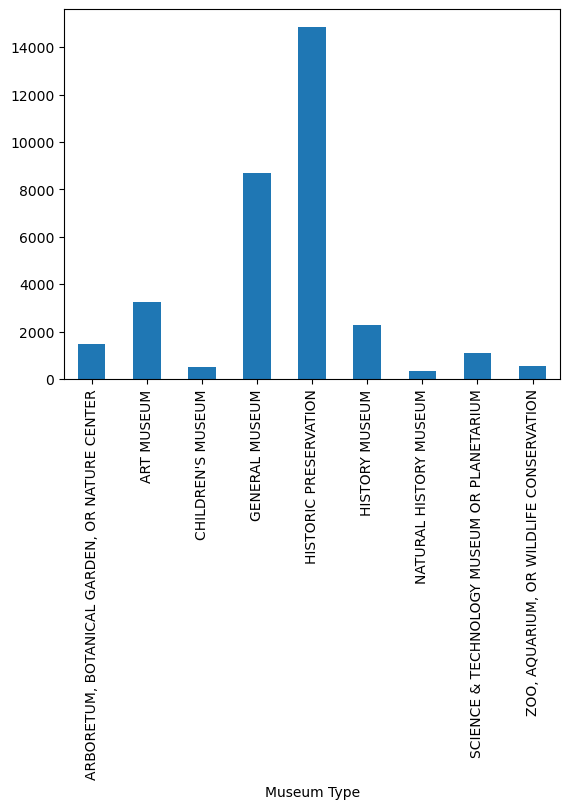

In [150]:
clean_copy.groupby('Museum Type').size().plot(kind='bar')

In [151]:
zoo_aqua = clean_copy[clean_copy['Museum Type'].eq('ZOO, AQUARIUM, OR WILDLIFE CONSERVATION')].copy()

In [152]:
zoo_aqua


,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
12,8409500006,ALASKA SEALIFE CENTER,ALASKA SEALIFE CENTER,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SEWARD,AK,SEWARD,AK,NaT,$nan,$nan,"687,455"
19,8400200087,ALASKA ZOO,ALASKA ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,ANCHORAGE,AK,ANCHORAGE,AK,2013-12-01,"$3,310,088.00","$2,393,748.00","687,455"
109,8400200167,OCEANSALASKA,OCEANSALASKA,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,KETCHIKAN,AK,KETCHIKAN,AK,2012-12-01,"$892,091.00","$534,898.00","687,455"
125,8400200126,SEWARD ASSOCIATION FOR THE ADVANCEMENT OF MARI...,SEWARD ASSOCIATION FOR THE ADVANCEMENT OF MARI...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SEWARD,AK,SEWARD,AK,2013-09-01,"$9,601,562.00","$9,469,200.00","687,455"
205,8400100279,ALABAMA WILDLIFE CENTER,ALABAMA WILDLIFE CENTER,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,PELHAM,AL,NaN,NaN,2013-12-01,"$463,192.00","$440,703.00","4,718,206"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32620,8405500307,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,KEWAUNEE,WI,KEWAUNEE,WI,2014-09-01,$0.00,$0.00,"5,641,996"
32621,8405500775,ZOOLOGICAL SOCIETY OF MILWAUKEE,ZOOLOGICAL SOCIETY OF MILWAUKEE COUNTY ENDOWME...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MILWAUKEE,WI,NaN,NaN,2014-09-01,"$4,286,798.00","$1,274,221.00","5,641,996"
32784,8409500139,OGLEBAY'S GOOD ZOO,OGLEBAY'S GOOD ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,WHEELING,WV,WHEELING,WV,NaT,$nan,$nan,"1,840,310"
32986,8405600127,MUSEUM OF NORTH AMERICAN WILDLIFE,MUSEUM OF NORTH AMERICAN WILDLIFE,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,CODY,WY,NaN,NaN,NaT,$nan,$nan,"546,043"


In [153]:
zoo = zoo_aqua['Museum Name'].str.contains('ZOO', case=False, na=False)
df_zoo = zoo_aqua[zoo]
df_zoo

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
19,8400200087,ALASKA ZOO,ALASKA ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,ANCHORAGE,AK,ANCHORAGE,AK,2013-12-01,"$3,310,088.00","$2,393,748.00","687,455"
207,8400100125,ALABAMA ZOOLOGICAL SOCIETY,ALABAMA ZOOLOGICAL SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,BIRMINGHAM,AL,NaN,NaN,2014-09-01,$0.00,$0.00,"4,718,206"
254,8400100241,BIRMINGHAM ZOO,BIRMINGHAM ZOO INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MOUNTAIN BRK,AL,NaN,NaN,2013-12-01,"$10,969,184.00","$8,932,428.00","4,718,206"
475,8400100240,MOBILE ZOO,MOBILE ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,WILMER,AL,NaN,NaN,2013-12-01,"$54,423.00","$53,441.00","4,718,206"
478,8400100213,MONTGOMERY AREA ZOOLOGICAL SOCIETY,MONTGOMERY AREA ZOOLOGICAL SOCIETY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MONTGOMERY,AL,MONTGOMERY,AL,2014-09-01,"$516,603.00","$502,005.00","4,718,206"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32575,8405500653,WILDLIFE EXOTIC AND ZOO ANIMAL MEDICINE CLUB,WILDLIFE EXOTIC AND ZOO ANIMAL MEDICINE CLUB,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MADISON,WI,NaN,NaN,NaT,$nan,$nan,"5,641,996"
32576,8405500233,WILDWOOD ZOO - CITY OF MARSHFIELD,WILDWOOD PARK ZOOLOGICAL SOCIETY INC OF MARSHF...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MARSHFIELD,WI,MINOCQUA,WI,2014-07-01,"$54,734.00","$39,333.00","5,641,996"
32620,8405500307,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY,ZOOLOGICAL SOCIETY OF KEWAUNEE COUNTY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,KEWAUNEE,WI,KEWAUNEE,WI,2014-09-01,$0.00,$0.00,"5,641,996"
32621,8405500775,ZOOLOGICAL SOCIETY OF MILWAUKEE,ZOOLOGICAL SOCIETY OF MILWAUKEE COUNTY ENDOWME...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MILWAUKEE,WI,NaN,NaN,2014-09-01,"$4,286,798.00","$1,274,221.00","5,641,996"


In [154]:
aqua = zoo_aqua['Museum Name'].str.contains('AQUARIUM', case=False, na=False)
df_aqua = zoo_aqua[aqua]
df_aqua

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
1313,8400400389,SONORAN SEA AQUARIUM,SONORAN SEA AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,TUCSON,AZ,NaN,NaN,2010-12-01,$0.00,$0.00,"6,280,362"
1498,8409500010,AQUARIUM OF THE BAY,AQUARIUM OF THE BAY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SAN FRANCISCO,CA,SAN FRANCISCO,CA,NaT,$nan,$nan,"36,604,337"
1499,8400601268,AQUARIUM OF THE PACIFIC,AQUARIUM OF THE PACIFIC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,LONG BEACH,CA,NaN,NaN,2013-12-01,"$38,286,191.00","$33,641,453.00","36,604,337"
1675,8400600622,CABRILLO MARINE AQUARIUM,FRIENDS OF CABRILLO MARINE AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SAN PEDRO,CA,NaN,NaN,2014-06-01,"$1,109,599.00","$980,785.00","36,604,337"
1806,8400601973,CENTRAL COAST AQUARIUM SOCIETY,CENTRAL COAST AQUARIUM SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SHELL BEACH,CA,NaN,NaN,2012-12-01,$0.00,$0.00,"36,604,337"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
30453,8405100567,POTOMAC VALLEY AQUARIUM SOCIETY,POTOMAC VALLEY AQUARIUM SOCIETY INC GERALD HOF...,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MERRIFIELD,VA,MERRIFIELD,VA,2013-12-01,$0.00,$0.00,"7,833,496"
31500,8409500149,POINT DEFIANCE ZOO & AQUARIUM,POINT DEFIANCE ZOO & AQUARIUM,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,TACOMA,WA,TACOMA,WA,NaT,$nan,$nan,"6,562,231"
31518,8405300542,PUGET SOUND AQUARIUM SOCIETY,PUGET SOUND AQUARIUM SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,DUPONT,WA,NaN,NaN,2014-07-01,$0.00,$0.00,"6,562,231"
31552,8405300426,SEATTLE AQUARIUM,SEATTLE AQUARIUM SOCIETY-SEAS,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,SEATTLE,WA,NaN,NaN,2013-12-01,"$15,301,907.00","$14,467,857.00","6,562,231"


In [155]:
pd.merge(df_zoo, df_aqua, how='outer')

,Museum ID,Museum Name,Legal Name,Museum Type,Institution Name,City (Administrative Location),State (Administrative Location),City (Physical Location),State (Physical Location),Tax Period,Income,Revenue,Population (2008)
0,8400100125,ALABAMA ZOOLOGICAL SOCIETY,ALABAMA ZOOLOGICAL SOCIETY,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,BIRMINGHAM,AL,NaN,NaN,2014-09-01,$0.00,$0.00,"4,718,206"
1,8400100213,MONTGOMERY AREA ZOOLOGICAL SOCIETY,MONTGOMERY AREA ZOOLOGICAL SOCIETY INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MONTGOMERY,AL,MONTGOMERY,AL,2014-09-01,"$516,603.00","$502,005.00","4,718,206"
2,8400100240,MOBILE ZOO,MOBILE ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,WILMER,AL,NaN,NaN,2013-12-01,"$54,423.00","$53,441.00","4,718,206"
3,8400100241,BIRMINGHAM ZOO,BIRMINGHAM ZOO INC,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,MOUNTAIN BRK,AL,NaN,NaN,2013-12-01,"$10,969,184.00","$8,932,428.00","4,718,206"
4,8400200087,ALASKA ZOO,ALASKA ZOO,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,ANCHORAGE,AK,ANCHORAGE,AK,2013-12-01,"$3,310,088.00","$2,393,748.00","687,455"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
350,8409502368,NAPLES ZOO AT CARIBBEAN GARDENS,NAPLES ZOO AT CARIBBEAN GARDENS,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,NAPLES,FL,NAPLES,FL,NaT,$nan,$nan,"18,527,305"
351,8409502390,OKLAHOMA CITY ZOO & BOTANICAL GARDEN,OKLAHOMA CITY ZOO & BOTANICAL GARDEN,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,OKLAHOMA CITY,OK,OKLAHOMA CITY,OK,NaT,$nan,$nan,"3,668,976"
352,8409502395,OREGON ZOO/HORTICULTURE,OREGON ZOO/HORTICULTURE,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,PORTLAND,OR,PORTLAND,OR,NaT,$nan,$nan,"3,768,748"
353,8409502442,RIVERBANKS ZOO & BOTANICAL GARDEN,RIVERBANKS ZOO & BOTANICAL GARDEN,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",NaN,COLUMBIA,SC,NaN,NaN,NaT,$nan,$nan,"4,528,996"


In [156]:
s_zoo_aqua = zoo_aqua.groupby('State (Administrative Location)').size().reset_index(name='Count').sort_values(by='Count', ascending=False)
s_zoo_aqua

,State (Administrative Location),Count
4,CA,47
9,FL,42
43,TX,39
34,NY,38
38,PA,21
48,WI,20
22,MI,19
35,OH,19
14,IL,17
24,MO,14


<Axes: ylabel='count'>

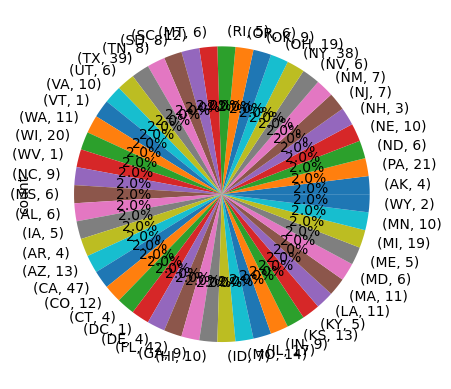

In [157]:
s_zoo_aqua.value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: title={'center': 'Number of Zoos and Aquariums by State'}, xlabel='State (Administrative Location)'>

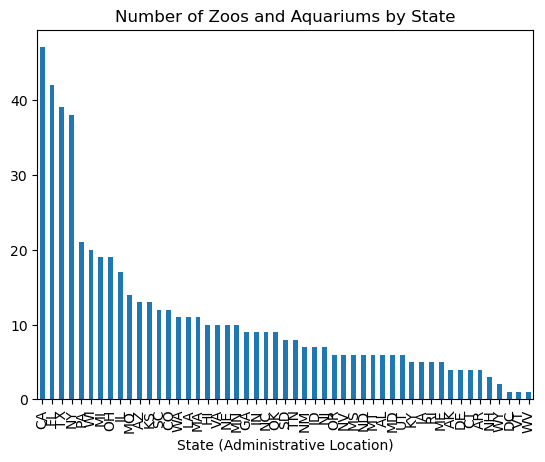

In [158]:
s_zoo_aqua.plot(x='State (Administrative Location)', y='Count', kind='bar', legend=False, title='Number of Zoos and Aquariums by State')

In [159]:
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

state_col = 'State (Administrative Location)'
type_col = 'Museum Type'

state_type_counts = (
    clean_copy.groupby([state_col, type_col])
    .size()
    .reset_index(name='Count')
)

states = sorted(state_type_counts[state_col].dropna().unique())

def plot_state_museum_types(selected_state):
    state_data = (
        state_type_counts[state_type_counts[state_col] == selected_state]
        .sort_values('Count', ascending=True)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(state_data[type_col], state_data['Count'])
    ax.set_title(f'Museum Type Distribution in {selected_state}')
    ax.set_xlabel('Count')
    ax.set_ylabel('Museum Type')
    ax.grid(axis='x', alpha=0.2)
    plt.tight_layout()
    plt.show()

state_dropdown = widgets.Dropdown(
    options=states,
    value=states[0],
    description='State:',
    layout=widgets.Layout(width='350px')
)

interactive_plot = widgets.interactive_output(
    plot_state_museum_types,
    {'selected_state': state_dropdown}
)

display(state_dropdown, interactive_plot)

Dropdown(description='State:', layout=Layout(width='350px'), options=('AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT'…

Output()

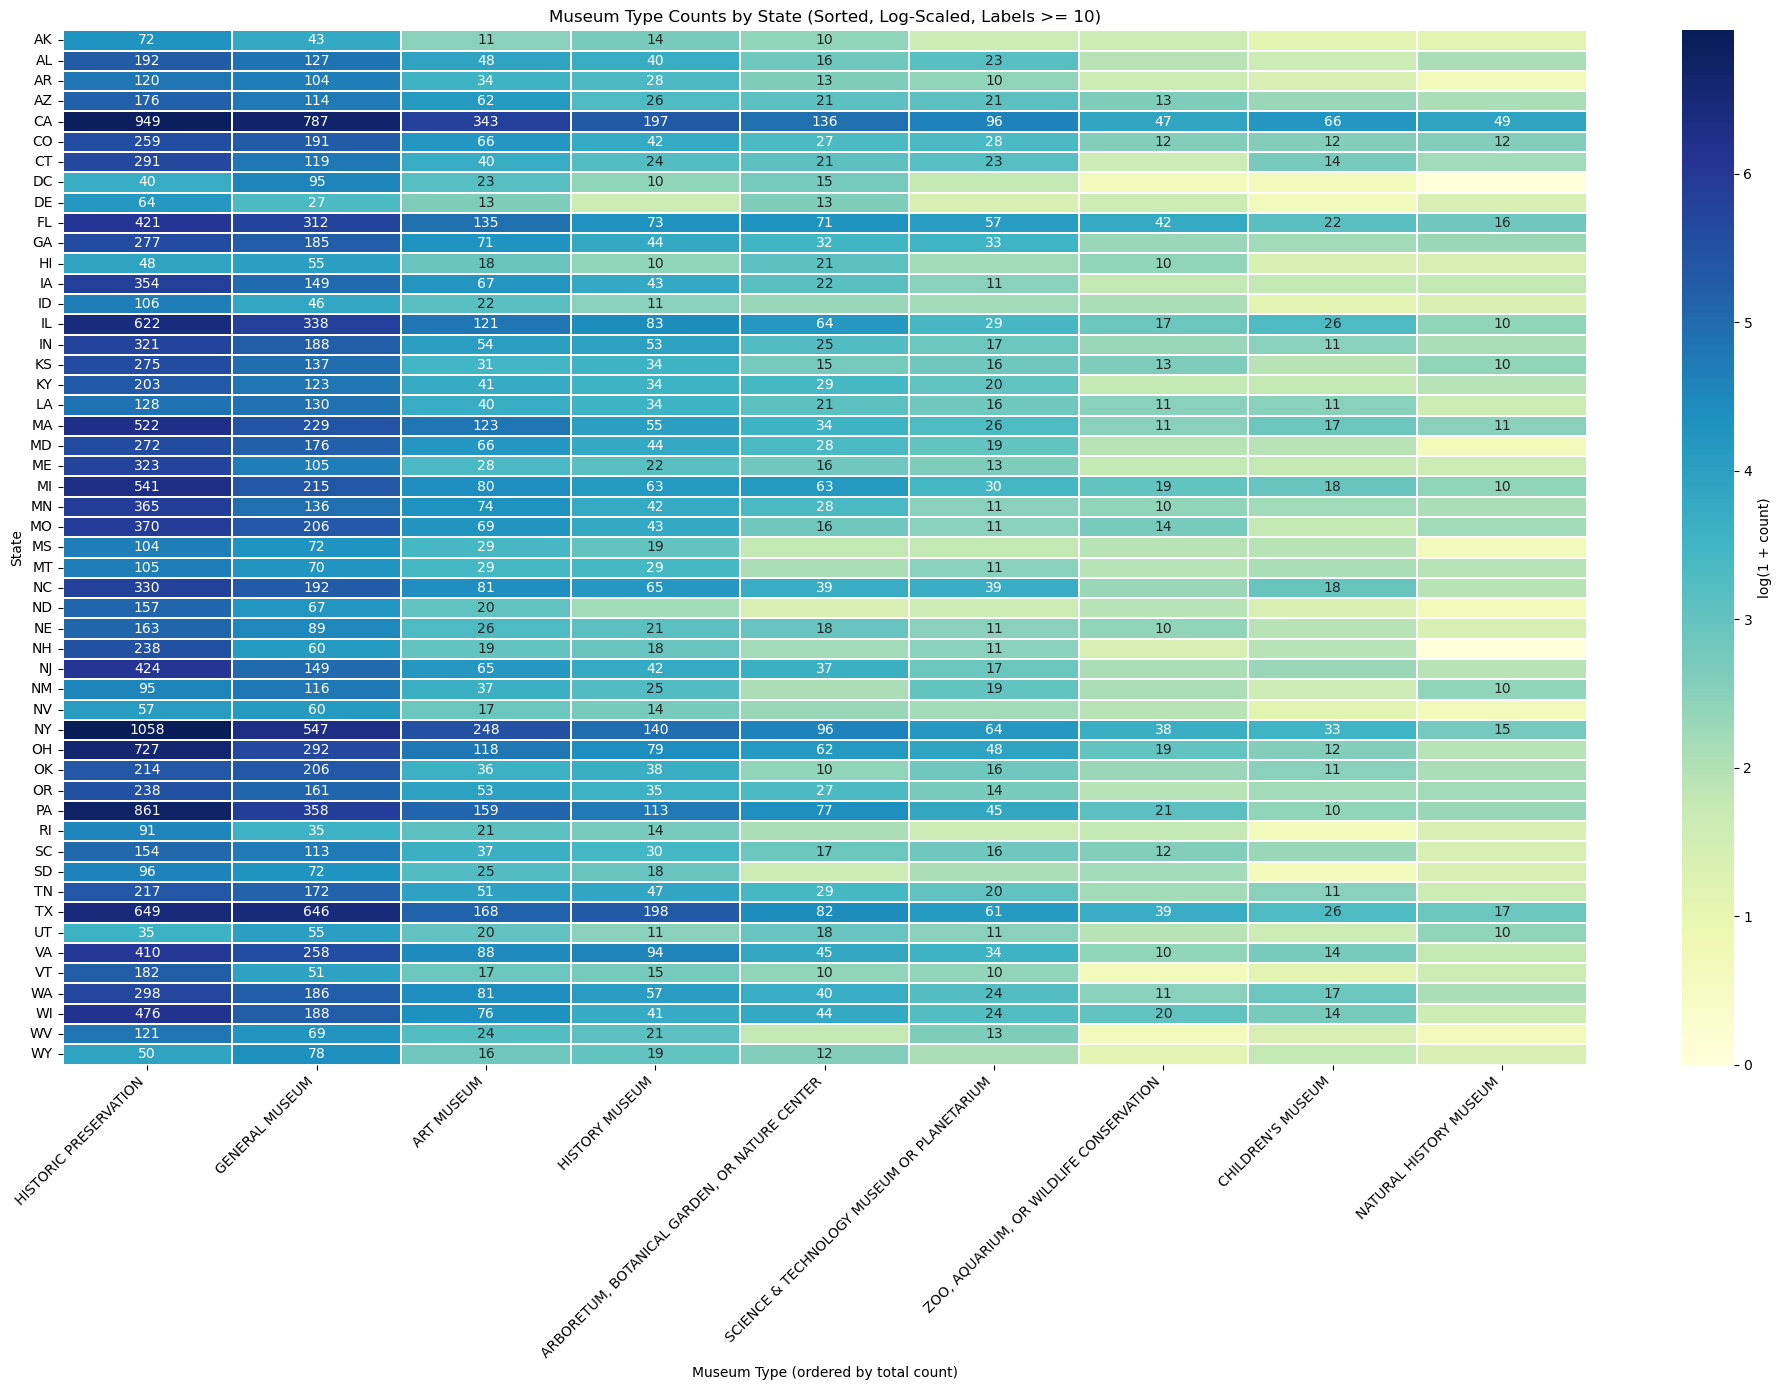

In [160]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

heatmap_data = (
    clean_copy.groupby(['State (Administrative Location)', 'Museum Type'])
    .size()
    .unstack(fill_value=0)
)

# 1) Order columns by total frequency so most common museum types appear first.
ordered_cols = heatmap_data.sum(axis=0).sort_values(ascending=False).index
heatmap_data = heatmap_data[ordered_cols]

# 2) Use log scaling for color intensity while keeping raw counts as labels.
heatmap_log = np.log1p(heatmap_data)

# 3) Keep the chart readable: hide zeros and only annotate values >= 10.
annot_labels = heatmap_data.astype(str).mask(heatmap_data < 10, '')

plt.figure(figsize=(20, 14))
ax = sns.heatmap(
    heatmap_log,
    cmap='YlGnBu',
    linewidths=0.2,
    linecolor='white',
    annot=annot_labels,
    fmt='',
    cbar_kws={'label': 'log(1 + count)'}
)

plt.title('Museum Type Counts by State (Sorted, Log-Scaled, Labels >= 10)')
plt.xlabel('Museum Type (ordered by total count)')
plt.ylabel('State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [161]:
revs = clean_copy['Revenue'].dropna().apply(lambda x: float(x.replace('$', '').replace(',', '')))
revs.describe()

count    2.229000e+04
mean     2.097605e+07
std      2.485197e+08
min     -2.127393e+06
25%      0.000000e+00
50%      3.307000e+03
75%      1.676960e+05
max      5.840349e+09
Name: Revenue, dtype: float64

In [162]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import ipywidgets as widgets
from IPython.display import display

state_col = 'State (Administrative Location)'
museum_col = 'Museum Name'
rev_col = 'Revenue'

# Convert revenue to numeric and keep only valid positive values.
rev_numeric = pd.to_numeric(
    clean_copy[rev_col].astype(str).str.replace(r'[\$,]', '', regex=True),
    errors='coerce'
)

state_revenue = clean_copy[[state_col, museum_col]].copy()
state_revenue['Revenue_num'] = rev_numeric

# Remove missing/blank state and museum names, and remove NA/zero revenue.
state_revenue[museum_col] = state_revenue[museum_col].astype(str).str.strip()
state_revenue[state_col] = state_revenue[state_col].astype(str).str.strip()
state_revenue = state_revenue[
    state_revenue[museum_col].ne('')
    & state_revenue[state_col].ne('')
    & state_revenue['Revenue_num'].notna()
    & state_revenue['Revenue_num'].gt(0)
]

# If duplicates exist, combine them so a museum appears once per state.
state_revenue = (
    state_revenue.groupby([state_col, museum_col], as_index=False)['Revenue_num']
    .sum()
)

states = sorted(state_revenue[state_col].unique())
max_rev = float(state_revenue['Revenue_num'].max())

def plot_state_revenue(selected_state, min_revenue):
    all_state_data = (
        state_revenue[state_revenue[state_col] == selected_state]
        .sort_values('Revenue_num', ascending=True)
        .reset_index(drop=True)
    )

    if all_state_data.empty:
        fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
        ax.text(0.5, 0.5, 'No museums with revenue > 0 for this state.', ha='center', va='center')
        ax.axis('off')
        plt.show()
        return

    # Dynamic significance threshold: top quartile in selected state.
    state_q75 = all_state_data['Revenue_num'].quantile(0.75)
    threshold = max(float(min_revenue), float(state_q75))

    state_data = all_state_data[all_state_data['Revenue_num'] >= threshold]

    if state_data.empty:
        fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
        ax.text(
            0.5,
            0.5,
            f'No museums meet threshold (${threshold:,.0f}) in {selected_state}.',
            ha='center',
            va='center'
        )
        ax.axis('off')
        plt.show()
        return

    # Keep the figure compact and remove top/bottom padding in the plotting area.
    fig_height = max(4, len(state_data) * 0.28)
    fig, ax = plt.subplots(figsize=(12, fig_height), constrained_layout=True)
    ax.barh(state_data[museum_col], state_data['Revenue_num'], color='#2E86AB')
    ax.set_title(
        f'Significant Museum Revenue in {selected_state} (threshold >= ${threshold:,.0f})',
        pad=6
    )
    ax.set_xlabel('Revenue (USD)')
    ax.set_ylabel('Museum')
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
    ax.grid(axis='x', alpha=0.2)

    # Remove internal whitespace at top/bottom of the bar area.
    ax.margins(y=0)
    ax.set_ylim(-0.5, len(state_data) - 0.5)

    plt.show()

state_dropdown = widgets.Dropdown(
    options=states,
    value=states[0],
    description='State:',
    layout=widgets.Layout(width='320px')
)

min_revenue_slider = widgets.FloatLogSlider(
    value=1e6,
    base=10,
    min=3,
    max=max(3, int(len(str(int(max_rev))) - 1)),
    step=0.1,
    description='Min rev:',
    readout_format=',.0f',
    layout=widgets.Layout(width='420px')
)

interactive_plot = widgets.interactive_output(
    plot_state_revenue,
    {
        'selected_state': state_dropdown,
        'min_revenue': min_revenue_slider,
    }
)

controls = widgets.HBox([state_dropdown, min_revenue_slider])
display(controls, interactive_plot)

Output()

In [191]:
#state_counts = clean_copy.groupby('State (Administrative Location)').size().reset_index(name='Count').sort_values(by='Count', ascending=False)
#state_counts["Count"] = state_counts["Count"].astype(int)
#state_pop = clean_copy.groupby('State (Administrative Location)').size().reset_index(name='Population (2008)').sort_values(by='State (Administrative Location)', ascending=True)
#state_pop["Population (2008)"] = state_pop["Population (2008)"].astype(int)
#per_capita = pd.merge(state_counts,state_pop, on="State (Administrative Location)", how="outer")
#state_pop
per_capita = clean_copy.groupby("State (Administrative Location)")["Population (2008)"].value_counts().reset_index(name="Count").sort_values(by="State (Administrative Location)", ascending=True)
per_capita["Count"] = per_capita["Count"].astype(int)
per_capita["Population (2008)"] = per_capita["Population (2008)"].astype(str).str.replace(r'[$\,]',"",regex=True)
per_capita["Population (2008)"] = per_capita["Population (2008)"].astype(int)
per_capita["per_capita"] = per_capita["Count"].div(per_capita["Population (2008)"])
per_capita.sort_values(by="per_capita", ascending=True)



,State (Administrative Location),Population (2008),Count,per_capita
9,FL,18527305,1149,0.000062
44,UT,2663029,170,0.000064
33,NV,2653630,174,0.000066
10,GA,9504843,668,0.000070
3,AZ,6280362,449,0.000071
4,CA,36604337,2670,0.000073
43,TX,24309039,1886,0.000078
27,NC,9309449,779,0.000084
25,MS,2947806,247,0.000084
40,SC,4528996,391,0.000086


In [34]:
revenue_num = pd.to_numeric(clean_copy['Revenue'].astype(str).str.replace(r'[\$,]', '', regex=True),errors='coerce')
museum_type_revenue = (clean_copy.assign(Revenue_num=revenue_num).groupby('Museum Type')['Revenue_num'].sum().reset_index().sort_values(by='Revenue_num', ascending=False))
museum_type_revenue['Revenue'] = museum_type_revenue['Revenue_num'].map('${:,.2f}'.format)
museum_type_revenue[['Museum Type', 'Revenue']]
museum_type_revenue

,Museum Type,Revenue_num,Revenue
1,ART MUSEUM,1.858520e+11,"$185,852,033,185.00"
3,GENERAL MUSEUM,1.104060e+11,"$110,406,048,625.00"
0,"ARBORETUM, BOTANICAL GARDEN, OR NATURE CENTER",5.778638e+10,"$57,786,382,965.00"
7,SCIENCE & TECHNOLOGY MUSEUM OR PLANETARIUM,4.709544e+10,"$47,095,435,425.00"
4,HISTORIC PRESERVATION,2.520482e+10,"$25,204,822,787.00"
6,NATURAL HISTORY MUSEUM,2.009211e+10,"$20,092,106,106.00"
5,HISTORY MUSEUM,1.907755e+10,"$19,077,554,830.00"
8,"ZOO, AQUARIUM, OR WILDLIFE CONSERVATION",1.601212e+09,"$1,601,211,797.00"
2,CHILDREN'S MUSEUM,4.404932e+08,"$440,493,179.00"
